## Extracción de Caracteristicas

Esta seccion aborda las caracteristicas a extraer para entrenar un modelo de clasificación

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, lfilter, filtfilt
from scipy.fft import rfft, rfftfreq
from scipy.stats import skew, kurtosis, entropy
import pywt
from typing import List, Tuple, Dict, Any
import os
import glob
import nolds
from joblib import Parallel, delayed
import algoritmos_deteccion as ad

In [ ]:
# ==============================================================================
# 1. Dominio del Tiempo
# ==============================================================================
def caracteristicas_tiempo(segmento: np.ndarray, rms_nominal: float) -> dict:
    """Extrae las características seleccionadas del dominio del tiempo."""
    
    rms_segmento_val = np.sqrt(np.mean(segmento**2))
    profundidad_relativa_val = rms_segmento_val / rms_nominal if rms_nominal > 1e-6 else 0.0
    pico_abs = np.max(np.abs(segmento))
    factor_cresta_val = pico_abs / rms_segmento_val if rms_segmento_val > 1e-6 else 0.0
    curtosis_val = kurtosis(segmento)
    
    return {
        'rms_segmento': rms_segmento_val,
        'profundidad_relativa': profundidad_relativa_val,
        'factor_cresta': factor_cresta_val,
        'curtosis': curtosis_val,
    }

# ==============================================================================
# 2. Dominio de la Frecuencia 
# ==============================================================================
def caracteristicas_frecuencia(segmento: np.ndarray) -> dict:
    """Extrae únicamente la energía espectral (FFT)."""
    n = len(segmento)
    if n < 2: return {'fft_energia': 0}

    fft_vals = np.fft.fft(segmento)[:n // 2]
    psd = np.abs(fft_vals)**2 / n
    energia_espectral = np.sum(psd)
    
    return {
        'fft_energia': energia_espectral,
    }

# ==============================================================================
# 3. Dominio Wavelet y Envolvente 
# ==============================================================================
def caracteristicas_wavelet(segmento: np.ndarray, wavelet: str = 'db4', max_level: int = 4) -> dict:
    """Extrae energía, entropía y desviación estándar de los coeficientes wavelet."""
    coeffs = pywt.wavedec(segmento, wavelet, level=max_level)
    caracteristicas = {}
    
    for i in range(1, len(coeffs)):
        nivel_coeffs = coeffs[-i]
        nivel = i
        
        caracteristicas[f'wavelet_energia_cD{nivel}'] = np.sum(nivel_coeffs**2)
        
        energia = caracteristicas[f'wavelet_energia_cD{nivel}']
        p = (nivel_coeffs**2) / energia if energia > 1e-6 else 0
        caracteristicas[f'wavelet_entropia_cD{nivel}'] = -np.sum(p * np.log2(p + 1e-12))
        
        caracteristicas[f'wavelet_std_cD{nivel}'] = np.std(nivel_coeffs)
        
    return caracteristicas

def caracteristicas_envolvente(senal: np.ndarray) -> dict:
    """Calcula la media y desviación estándar de la envolvente de Hilbert."""
    envolvente = np.abs(hilbert(senal))
    return {
        'env_media': np.mean(envolvente),
        'env_std': np.std(envolvente)
    }

# ==============================================================================
# 4. FUNCIÓN MAESTRA 
# ==============================================================================
def extraer_caracteristicas(segmento_evento: np.ndarray, fs: int, rms_nominal_val: float) -> dict:
    """
    Orquesta la extracción del conjunto final de características "Top 1".
    """
    caracteristicas = {}
    
    # Llama a las versiones ajustadas y a las que no necesitaron cambios
    caracteristicas.update(caracteristicas_tiempo(segmento_evento, rms_nominal_val))
    caracteristicas.update(caracteristicas_frecuencia(segmento_evento))
    caracteristicas.update(caracteristicas_wavelet(segmento_evento))
    caracteristicas.update(caracteristicas_envolvente(segmento_evento))
    
    # La lista final de características que se quiere mantener
    caracteristicas_top_1_requeridas = [
        'curtosis', 'env_media', 'env_std', 'factor_cresta', 'fft_energia', 
        'profundidad_relativa', 'rms_segmento', 'wavelet_energia_cD1', 
        'wavelet_energia_cD2', 'wavelet_energia_cD3', 'wavelet_energia_cD4', 
        'wavelet_entropia_cD1', 'wavelet_entropia_cD2', 'wavelet_entropia_cD3', 
        'wavelet_entropia_cD4', 'wavelet_std_cD1','wavelet_std_cD2','wavelet_std_cD3','wavelet_std_cD4'
    ]
    
    # Filtrar el diccionario para devolver solo las claves requeridas
    caracteristicas_filtradas = {clave: valor for clave, valor in caracteristicas.items() if clave in caracteristicas_top_1_requeridas}
    
    return caracteristicas_filtradas

In [ ]:
def procesar_un_archivo(etiqueta, ruta_archivo, fs):
    """Procesa un único archivo de señales y devuelve sus características y duraciones."""
    print(f"-> Iniciando procesamiento para: '{etiqueta}'")
    try:
        df_senales = pd.read_csv(ruta_archivo, index_col=0)
    except FileNotFoundError:
        return (None, []) # Devuelve una tupla vacía si el archivo no existe
    
    lista_features = []
    lista_duraciones = []
    for nombre_columna in df_senales.columns:
        # (Lógica de detección, consolidación y extracción idéntica a la anterior)
        senal_completa = df_senales[nombre_columna].values
        eventos_detectados = ad.detectar_eventos_con_fusion(senal_completa, fs)
        eventos_consolidados = []
        if len(eventos_detectados) > 1:
            inicio_consolidado, fin_consolidado = eventos_detectados[0][0], eventos_detectados[-1][1]
            eventos_consolidados.append((inicio_consolidado, fin_consolidado))
        elif len(eventos_detectados) == 1:
            eventos_consolidados = eventos_detectados
        
        if not eventos_consolidados: continue
        
        rms_nom_completa = ad.rms_nominal(senal_completa, fs)
        for inicio, fin in eventos_consolidados:
            segmento_evento = senal_completa[inicio:fin]
            if len(segmento_evento) == 0: continue
            
            caracteristicas = extraer_caracteristicas(segmento_evento, fs, rms_nom_completa)
            duracion = fin - inicio
            caracteristicas['etiqueta'] = etiqueta
            caracteristicas['columna_origen'] = nombre_columna
            caracteristicas['duracion_muestras'] = duracion
            lista_features.append(caracteristicas)
            lista_duraciones.append(duracion)

    if not lista_features: return (None, [])
    
    print(f"-> Finalizado: '{etiqueta}'")
    return (pd.DataFrame(lista_features), lista_duraciones)

def generar_features_normales(ruta_archivo_normal, duraciones_reales, fs, num_muestras):
    """Genera las características para la clase Normal."""
    print("\n--- Procesando la clase 'Normal' ---")
    try:
        df_normales = pd.read_csv(ruta_archivo_normal, index_col=0)
    except FileNotFoundError:
        print(f"  -> ERROR: No se encontró el archivo de señales normales.")
        return None
        
    senales_normales_pool = [df_normales[col].values for col in df_normales.columns]
    lista_features_normales = []

    for _ in range(num_muestras):
        duracion_aleatoria = np.random.choice(duraciones_reales)
        idx_senal = np.random.randint(0, len(senales_normales_pool))
        senal_completa = senales_normales_pool[idx_senal]

        if len(senal_completa) > duracion_aleatoria:
            inicio = np.random.randint(0, len(senal_completa) - duracion_aleatoria)
            segmento = senal_completa[inicio : inicio + duracion_aleatoria]
            rms_nom = ad.rms_nominal(senal_completa, fs)
            caracteristicas = extraer_caracteristicas(segmento, fs, rms_nom)
            caracteristicas['etiqueta'] = 'Normal'
            caracteristicas['columna_origen'] = f'normal_from_pool_{idx_senal}'
            caracteristicas['duracion_muestras'] = duracion_aleatoria
            lista_features_normales.append(caracteristicas)

    if not lista_features_normales: return None
    
    return pd.DataFrame(lista_features_normales)


# ==============================================================================
# SECCIÓN DE CONFIGURACIÓN Y ORQUESTACIÓN
# ==============================================================================
if __name__ == '__main__':
    
    FS = 7200
    NUM_MUESTRAS_NORMALES = 4100
    DIRECTORIO_SALIDA = 'Dataset_Final_Generado'
    DIRECTORIO_TEMP = os.path.join(DIRECTORIO_SALIDA, 'temp')
    NOMBRE_ARCHIVO_CONSOLIDADO = 'Dataset_Caracteristicas_Final.csv'

    ARCHIVOS_A_PROCESAR = {
        'Sag': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag\Clase_1_sag.csv',
        'Sag_Armonico': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Armonic\Clase_2_Armonico.csv',
        'Sag_Multiple': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Multiple\Clase_3_sagmultiple.csv',
        'Sag_Notch': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Notch\Clase_4_sagnotch.csv',
        'Sag_Transitorios': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Transitorios\Clase_5_Transitorios.csv'
    }
    RUTA_ARCHIVO_NORMAL = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Normal\Clase_0_normal.csv'

    # --- LÓGICA PRINCIPAL OPTIMIZADA ---
    os.makedirs(DIRECTORIO_TEMP, exist_ok=True)
    
    # --- LÓGICA PRINCIPAL PARALELIZADA ---
    print("--- FASE 1: Procesando archivos de eventos en paralelo ---")
    
    # n_jobs=-1 usa todos los núcleos disponibles de tu CPU
    resultados_paralelos = Parallel(n_jobs=-1)(
        delayed(procesar_un_archivo)(etiqueta, ruta, FS) for etiqueta, ruta in ARCHIVOS_A_PROCESAR.items()
    )

    # Desempaquetar los resultados
    lista_dfs_eventos = [res[0] for res in resultados_paralelos if res[0] is not None]
    todas_las_duraciones = [duracion for res in resultados_paralelos for duracion in res[1]]
    
    print(f"\nSe procesaron {len(lista_dfs_eventos)} clases de eventos.")

    # FASE 2: Procesar clase normal (esto es rápido, no necesita paralelismo)
    if todas_las_duraciones:
        df_normal = generar_features_normales(RUTA_ARCHIVO_NORMAL, todas_las_duraciones, FS, NUM_MUESTRAS_NORMALES)
        if df_normal is not None:
            lista_dfs_eventos.append(df_normal)

    # FASE 3: Consolidar todos los resultados
    print("\n--- FASE 3: Consolidando todos los resultados ---")
    if not lista_dfs_eventos:
        print("No se generaron características para consolidar.")
    else:
        df_final = pd.concat(lista_dfs_eventos, ignore_index=True).fillna(0)
        
        columnas_info = ['etiqueta', 'columna_origen', 'duracion_muestras']
        columnas_features = sorted([col for col in df_final.columns if col not in columnas_info])
        df_final = df_final[columnas_info + columnas_features]

        os.makedirs(DIRECTORIO_SALIDA, exist_ok=True)
        ruta_salida_completa = os.path.join(DIRECTORIO_SALIDA, NOMBRE_ARCHIVO_CONSOLIDADO)
        df_final.to_csv(ruta_salida_completa, index=False)
        
        print(f"\n¡ÉXITO! Se guardó el dataset final en '{ruta_salida_completa}'")
        print("Conteo de eventos por clase en el dataset final:")
        print(df_final['etiqueta'].value_counts())

## PCA Analisis de  Componentes Principales

Dimensiones originales de X: (24600, 19)


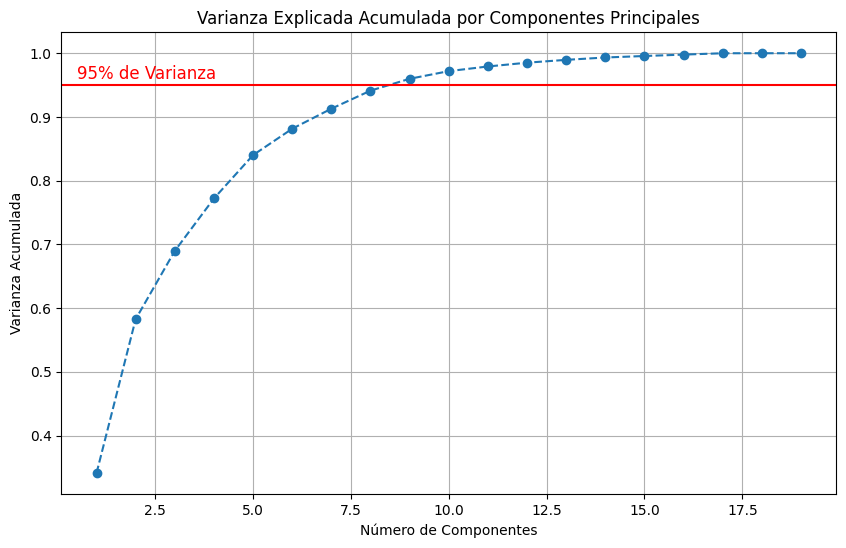

In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Carga tu dataset (si no lo tienes ya cargado)
csv = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Final_Generado\Dataset_Caracteristicas_Final.csv'
df_final = pd.read_csv(csv)

# Separa las características (X) y la etiqueta (y)
X = df_final.drop(columns=['etiqueta', 'columna_origen','duracion_muestras']) # Quitamos las columnas no numéricas/identificadoras
y = df_final['etiqueta']

print("Dimensiones originales de X:", X.shape)

# Crea el objeto escalador
scaler = StandardScaler()

# Ajusta y transforma los datos
X_scaled = scaler.fit_transform(X)

# 1. Aplicar PCA para conservar TODOS los componentes inicialmente
pca = PCA()
X_pca_temp = pca.fit_transform(X_scaled)

# 2. Calcular la varianza explicada acumulada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 3. Graficar la varianza explicada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.96, '95% de Varianza', color = 'red', fontsize=12)
plt.show()

In [41]:
# Elige el número de componentes (ej. 10)
N_COMPONENTS = 8

# Aplica PCA con el número de componentes seleccionado
pca_final = PCA(n_components=N_COMPONENTS)
X_pca_final = pca_final.fit_transform(X_scaled)

print("Dimensiones de X después de PCA:", X_pca_final.shape)

Dimensiones de X después de PCA: (24600, 8)


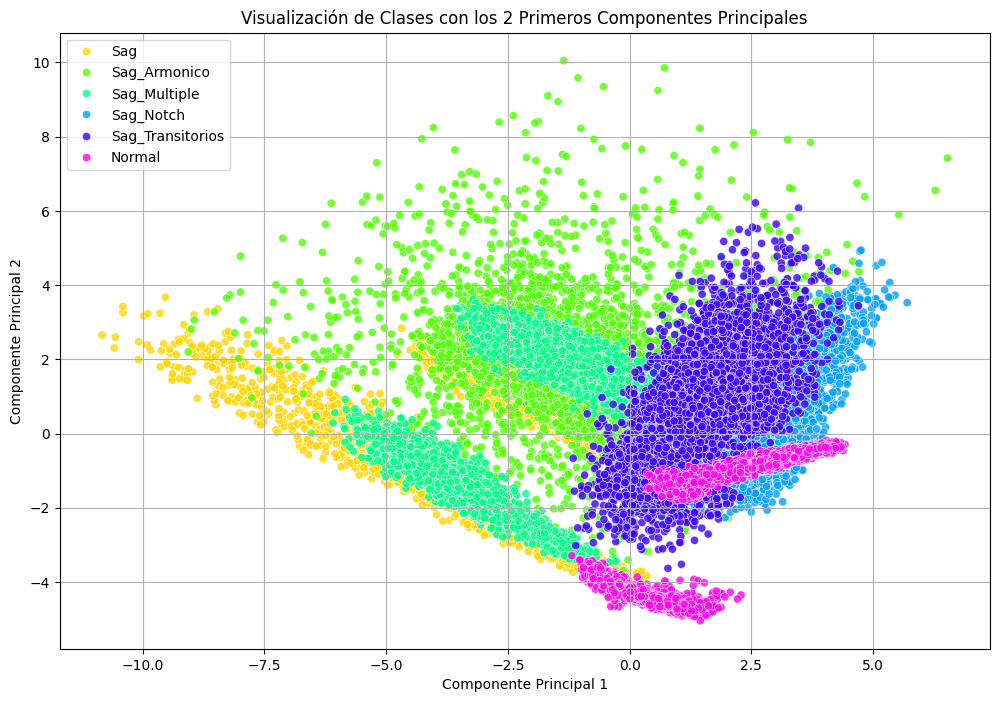

In [42]:
# Crea un DataFrame con los dos primeros componentes y las etiquetas
df_pca_viz = pd.DataFrame(
    data=X_pca_final[:, 0:2], 
    columns=['Componente Principal 1', 'Componente Principal 2']
)
df_pca_viz['etiqueta'] = y

# Grafica con Seaborn
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Componente Principal 1', 
    y='Componente Principal 2',
    hue='etiqueta',
    palette=sns.color_palette("hsv", len(y.unique())), # Colores distintos para cada clase
    data=df_pca_viz,
    alpha=0.8
)
plt.title('Visualización de Clases con los 2 Primeros Componentes Principales')
plt.legend(loc='best')
plt.grid()
plt.show()

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Dividir los datos transformados por PCA
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_final,  # <--- Usamos los datos de PCA
    y,
    test_size=0.3,
    random_state=42,
    stratify=y # Importante para clases desbalanceadas
)

# Entrenar el modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluar el modelo
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

                  precision    recall  f1-score   support

          Normal       1.00      1.00      1.00      1230
             Sag       0.92      0.98      0.95      1230
    Sag_Armonico       0.99      0.91      0.95      1230
    Sag_Multiple       0.98      0.96      0.97      1230
       Sag_Notch       0.98      1.00      0.99      1230
Sag_Transitorios       0.98      1.00      0.99      1230

        accuracy                           0.97      7380
       macro avg       0.97      0.97      0.97      7380
    weighted avg       0.97      0.97      0.97      7380



In [39]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Asumimos que X_pca_final y 'y' ya están definidos como antes
# y: contiene ['Sag', 'Normal', 'Sag_Armonico', ...]

# --- ¡Paso Clave: Codificar las etiquetas! ---
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# y_encoded ahora contiene [1, 3, 2, ...] en lugar de texto.
# Puedes ver el mapeo así:
# print(le.classes_) -> ['Normal', 'Sag', 'Sag_Armonico', ...]

In [43]:
# Dividir los datos (usando las etiquetas codificadas)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_final,
    y_encoded, # <-- Usar y_encoded
    test_size=0.3,
    random_state=42,
    stratify=y_encoded # <-- Usar y_encoded para estratificar
)

# Crear y entrenar el modelo XGBoost
# Usamos parámetros iniciales robustos
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax', # Especifica que es un problema multiclase
    num_class=len(le.classes_), # Le dice cuántas clases hay
    use_label_encoder=False,   # Opción recomendada para versiones nuevas
    eval_metric='mlogloss'     # Métrica de evaluación durante el entrenamiento
)

print("Entrenando el modelo XGBoost...")
xgb_model.fit(X_train, y_train)

# Realizar predicciones
y_pred_encoded = xgb_model.predict(X_test)

# --- Para el reporte, usa los nombres de clase originales ---
y_pred = le.inverse_transform(y_pred_encoded)
y_test_labels = le.inverse_transform(y_test)

# Evaluar el modelo
print("\n--- Reporte de Clasificación con XGBoost ---")
print(classification_report(y_test_labels, y_pred))

Entrenando el modelo XGBoost...


c:\Users\Juan_Saa\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:04:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Reporte de Clasificación con XGBoost ---
                  precision    recall  f1-score   support

          Normal       1.00      1.00      1.00      1230
             Sag       0.91      0.96      0.93      1230
    Sag_Armonico       0.97      0.90      0.93      1230
    Sag_Multiple       0.98      0.95      0.96      1230
       Sag_Notch       0.98      1.00      0.99      1230
Sag_Transitorios       0.97      0.99      0.98      1230

        accuracy                           0.97      7380
       macro avg       0.97      0.97      0.97      7380
    weighted avg       0.97      0.97      0.97      7380

